# 02. Agentic RAG

> 검색을 항상 무조건 한 번만 돌리는 건 비효율적이에요. 관련성 체크 · 웹 폴백 · 쿼리 재작성으로 **에이전트 스스로 검색을 결정**하는 Agentic RAG를 만들어요.

이전 노트북(`01-Graph-Based-RAG.ipynb`)에서는 Naive RAG 그래프를 구현했어요. 이번 노트북에서는 RAG 파이프라인을 단계별로 고도화하는 방법을 배워요.

### 왜 Naive RAG로는 부족한가요?

Naive RAG는 항상 "검색 → 생성"을 실행해요. 하지만 실제 사용에서는 이런 문제가 생겨요:

| 상황 | Naive RAG의 문제 | 해결 방향 |
|------|-----------------|----------|
| PDF에 없는 최신 정보를 물어봄 | 무관한 문서로 엉뚱한 답변 생성 | 관련성 체크 + 웹 검색 폴백 |
| "서울 날씨"처럼 검색이 불필요한 질문 | 불필요한 검색 비용 발생 | 에이전트가 검색 여부 자율 판단 |
| "앤스로픽 투자"처럼 모호한 질문 | 벡터 검색 품질 저하 | 쿼리 재작성으로 검색어 최적화 |

> 🔑 **핵심 개념**: Naive RAG가 **자동판매기**라면, Agentic RAG는 **경험 많은 사서**예요. 자동판매기는 버튼을 누르면 무조건 음료를 주지만, 사서는 "이 질문에는 이 책이 필요하겠다", "이건 책 없이도 답할 수 있겠다"를 스스로 판단해요.

**이 노트북의 구성**

1. **관련성 체크(Groundedness Check)**: 검색 문서와 질문의 관련성을 평가해 분기 처리
2. **웹 검색 폴백(Web Search Fallback)**: 관련 문서가 없으면 Tavily로 웹 검색
3. **쿼리 재작성(Query Rewrite)**: 검색 전 LLM으로 질문을 최적화
4. **Agentic RAG**: 에이전트가 도구 사용 여부를 스스로 결정하는 완전한 에이전트 기반 시스템

## 학습 목표

이 노트북을 마치면 다음을 할 수 있어요:

1. `GroundednessChecker` 없이 LLM 기반 관련성 평가기를 직접 구현할 수 있어요
2. 조건부 엣지(Conditional Edges)로 관련성에 따라 흐름을 분기할 수 있어요
3. Tavily 웹 검색을 폴백 전략으로 연결해 무한 루프를 방지할 수 있어요
4. `create_retriever_tool`과 `ToolNode`를 사용해 완전한 Agentic RAG를 구축할 수 있어요

## 사전 지식

- `01-Graph-Based-RAG.ipynb` — Naive RAG 그래프, StateGraph 기초
- `05_Agent_Development/02-Tools-V1.ipynb` — Tool 정의와 ToolNode 사용법
- Pydantic BaseModel과 structured output 개념

## 전체 아키텍처

이번 노트북에서 구현할 Agentic RAG의 최종 형태예요. 각 단계를 순서대로 구현하면서 최종 아키텍처에 도달해요.

```mermaid
flowchart TD
    A([사용자 질문]) --> B[에이전트<br/>agent]
    B -- 도구 호출 --> C[PDF 검색<br/>retrieve]
    B -- 도구 불필요 --> Z([종료 END])
    C --> D{문서 관련성 평가<br/>grade_documents}
    D -- 관련 있음 --> E[답변 생성<br/>generate]
    D -- 관련 없음 --> F[쿼리 재작성<br/>rewrite]
    F --> B
    E --> Z

    classDef input fill:#d4edda,stroke:#28a745,color:#155724
    classDef process fill:#cce5ff,stroke:#007bff,color:#004085
    classDef output fill:#fff3cd,stroke:#ffc107,color:#856404
    classDef decision fill:#f8d7da,stroke:#dc3545,color:#721c24
    classDef storage fill:#e2d5f1,stroke:#6f42c1,color:#3d1f6e

    class A input
    class B,C,E,F process
    class D decision
    class Z output
```

| 구성 요소 | 역할 | 핵심 기술 |
|----------|------|----------|
| `agent` | 도구 사용 여부 결정 | `model.bind_tools()` + `tools_condition` |
| `retrieve` | PDF 문서 검색 | `create_retriever_tool` + `ToolNode` |
| `grade_documents` | 문서 관련성 평가 | `GradeDocuments` Pydantic + structured output |
| `rewrite` | 질문 최적화 | LLM 기반 쿼리 재작성 |
| `generate` | 최종 답변 생성 | RAG 프롬프트 + LLM |

> 🎯 **강의 포인트**: Agentic RAG는 LLM이 수동적으로 검색 → 생성만 하는 것이 아니라, **언제 검색할지 스스로 결정**해요. 이것이 일반 RAG와 Agentic RAG의 핵심 차이예요.

## 1. 환경 설정

In [1]:
# ---------------------------------------------------
# 환경 변수 로드
# ---------------------------------------------------
# .env 파일에 OPENAI_API_KEY, TAVILY_API_KEY 가 있어야 해요
from dotenv import load_dotenv

load_dotenv(override=True)

True

In [2]:
# ---------------------------------------------------
# LangSmith 추적 설정 (선택)
# ---------------------------------------------------
# LangSmith 추적을 활성화하면 그래프 실행 과정을 시각적으로 디버깅할 수 있어요
import os

# os.environ["LANGCHAIN_TRACING_V2"] = "true"  # 추적 활성화
# os.environ["LANGCHAIN_PROJECT"] = "LangGraph-Agentic-RAG"  # 프로젝트 이름

## 2. RAG 유틸리티 — PDF 로더와 포맷터

이전 노트북에서 사용한 PDF 기반 Retrieval Chain을 그대로 활용해요.

> 🔑 **핵심 개념**: `pdf_retriever`와 `pdf_chain`을 분리해두면 LangGraph의 각 노드에서 독립적으로 활용할 수 있어요. 검색 단계와 생성 단계를 별도 노드로 설계할 수 있기 때문이에요.

In [3]:
# ---------------------------------------------------
# RAG 유틸리티 함수 정의
# ---------------------------------------------------
# format_docs: 검색된 Document 객체들을 XML 형태의 문자열로 변환해요
# 이 형식은 LLM이 각 문서를 구별하기 좋아요

def format_docs(docs: list) -> str:
    """검색된 문서들을 XML 형태의 문자열로 포맷팅해요."""
    return "\n".join(
        [
            f"<document><content>{doc.page_content}</content>"
            f"<source>{doc.metadata['source']}</source>"
            f"<page>{int(doc.metadata.get('page', 0)) + 1}</page></document>"
            for doc in docs
        ]
    )

In [4]:
# !uv add pdfplumber faiss-cpu

In [5]:
# ---------------------------------------------------
# PDF 문서 로드 및 Retriever / Chain 생성
# ---------------------------------------------------
# 이 노트북에서 사용하는 문서:
#   - 소프트웨어정책연구소(SPRi) - 2023년 12월호 AI 브리프
#   - 최신 AI 동향, 기업 투자, 기술 연구 내용을 담고 있어요

import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

from langchain_community.document_loaders import PDFPlumberLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_openai import OpenAIEmbeddings
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain.chat_models import init_chat_model

# PDF 파일 경로 (data 폴더 아래에 있어요)
PDF_PATH = "data/SPRI_AI_Brief_2023년12월호_F.pdf"

# PDF 로드
loader = PDFPlumberLoader(PDF_PATH)
docs = loader.load()
print(f"총 {len(docs)}페이지 로드됨")

# 텍스트 청킹 (chunk_size=1200, overlap=200)
splitter = RecursiveCharacterTextSplitter(chunk_size=1200, chunk_overlap=200)
splits = splitter.split_documents(docs)
print(f"총 {len(splits)}개 청크 생성됨")

# FAISS 벡터스토어 생성
embedding = OpenAIEmbeddings(model="text-embedding-3-small")
vectorstore = FAISS.from_documents(splits, embedding)

# Retriever 설정 (top-4 유사 문서 검색)
pdf_retriever = vectorstore.as_retriever(search_kwargs={"k": 4})
# Retriever 준비 완료

총 23페이지 로드됨
총 40개 청크 생성됨


In [6]:
# ---------------------------------------------------
# RAG Chain 생성
# ---------------------------------------------------
# RAG 체인: context + question + chat_history -> 답변
# 이 체인은 각 노드에서 답변 생성 시 활용해요

rag_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            """당신은 문서 기반 질의응답 전문가예요. 주어진 컨텍스트를 바탕으로 정확하고 도움이 되는 답변을 제공해요.

컨텍스트:
{context}

이전 대화:
{chat_history}

컨텍스트에 없는 내용은 모른다고 솔직하게 답해주세요. 출처(source)와 페이지 번호가 있으면 함께 알려주세요.""",
        ),
        ("human", "{question}"),
    ]
)

# 기본 모델: gpt-4o-mini (비용 효율적)
base_llm = init_chat_model("openai:gpt-4o-mini")

pdf_chain = rag_prompt | base_llm | StrOutputParser()
# RAG Chain 준비 완료

## 3. 관련성 체크 — Groundedness Check

Naive RAG에서는 검색된 문서가 질문과 실제로 관련 있는지 확인하지 않고 바로 답변을 생성했어요. 관련성 체크(Groundedness Check)를 추가하면 검색 품질을 보장할 수 있어요.

```mermaid
flowchart LR
    A([질문 입력]) --> B[문서 검색<br/>retrieve]
    B --> C{관련성 체크<br/>relevance_check}
    C -- yes --> D[답변 생성<br/>llm_answer]
    C -- no --> B
    D --> E([답변 출력])

    classDef input fill:#d4edda,stroke:#28a745,color:#155724
    classDef process fill:#cce5ff,stroke:#007bff,color:#004085
    classDef output fill:#fff3cd,stroke:#ffc107,color:#856404
    classDef decision fill:#f8d7da,stroke:#dc3545,color:#721c24

    class A input
    class B,D process
    class C decision
    class E output
```

> 🔑 **핵심 개념**: 관련성 체크는 LLM에게 "이 문서가 질문에 답하는 데 도움이 되나요? yes/no"를 구조화된 출력으로 물어보는 방식이에요. `with_structured_output()`을 사용하면 Pydantic 모델로 타입 안전한 응답을 받을 수 있어요.

> ⚠️ **자주 하는 실수**: 관련성이 없을 때 단순히 `retrieve`로 되돌아가면 **무한 루프**가 발생해요. `recursion_limit`을 설정하고 `GraphRecursionError`를 잡는 것이 중요해요. 이 문제는 다음 섹션에서 웹 검색으로 해결해요.

In [7]:
# ---------------------------------------------------
# 관련성 체크 그래프 — State 정의
# ---------------------------------------------------
# relevance 필드: "yes" 또는 "no" 값을 저장해요
# 조건부 엣지에서 다음 노드를 결정하는 데 사용해요

from typing import Annotated, TypedDict
from langgraph.graph.message import add_messages


class GraphState(TypedDict):
    question: Annotated[str, "사용자 질문"]      # 사용자 질문
    context: Annotated[str, "검색된 문서"]        # 검색된 문서 (포맷팅 후)
    answer: Annotated[str, "생성된 답변"]         # 최종 답변
    messages: Annotated[list, add_messages]        # 대화 히스토리 (누적)
    relevance: Annotated[str, "관련성 여부"]      # 관련성 체크 결과 (yes/no)

In [8]:
# ---------------------------------------------------
# 관련성 평가기 구현
# ---------------------------------------------------
# GroundednessChecker 없이 직접 구현해요
# with_structured_output()으로 "yes"/"no" 이진 응답을 보장해요

from pydantic import BaseModel, Field
from langchain_core.prompts import PromptTemplate


class RelevanceScore(BaseModel):
    """검색 문서와 질문의 관련성 평가 결과예요."""

    score: str = Field(
        description="문서가 질문과 관련이 있으면 'yes', 없으면 'no'"
    )


# 관련성 평가 프롬프트
relevance_prompt = PromptTemplate(
    template="""다음 문서가 질문에 답변하는 데 관련이 있는지 평가해주세요.

질문: {question}

검색된 문서:
{context}

문서에 질문과 관련된 키워드나 의미가 포함되어 있으면 'yes', 없으면 'no'로만 답해주세요.""",
    input_variables=["question", "context"],
)

# 관련성 평가 체인 (구조화된 출력으로 yes/no 보장)
# 경량 모델로 비용 효율적으로 평가해요
relevance_checker = relevance_prompt | init_chat_model("openai:gpt-4o-mini").with_structured_output(RelevanceScore)

# 관련성 평가기 준비 완료

In [9]:
# ---------------------------------------------------
# 노드 함수 정의 — 관련성 체크 버전
# ---------------------------------------------------

def retrieve_document(state: GraphState) -> GraphState:
    """PDF 문서에서 관련 내용을 검색하는 노드예요."""
    # 질문으로 벡터 검색을 수행해요
    retrieved_docs = pdf_retriever.invoke(state["question"])
    # 검색 결과를 XML 형태로 포맷팅해요
    context = format_docs(retrieved_docs)
    return {"context": context}


def relevance_check(state: GraphState) -> GraphState:
    """검색된 문서와 질문의 관련성을 평가하는 노드예요."""
    response = relevance_checker.invoke(
        {"question": state["question"], "context": state["context"]}
    )
    print(f"==== [관련성 체크] ==== {response.score}")
    return {"relevance": response.score}  # "yes" 또는 "no"


def llm_answer(state: GraphState) -> GraphState:
    """검색된 문서를 기반으로 답변을 생성하는 노드예요."""
    # 대화 히스토리를 문자열로 변환해요
    chat_history = "\n".join(
        [f"{m.type}: {m.content}" for m in state["messages"]]
    ) if state.get("messages") else ""

    response = pdf_chain.invoke(
        {
            "question": state["question"],
            "context": state["context"],
            "chat_history": chat_history,
        }
    )
    return {
        "answer": response,
        "messages": [("user", state["question"]), ("assistant", response)],
    }


def is_relevant(state: GraphState) -> str:
    """관련성에 따라 다음 노드를 결정하는 라우팅 함수예요."""
    # relevance 값에 따라 분기해요
    if state["relevance"] == "yes":
        return "relevant"      # 관련 있음 -> 답변 생성
    else:
        return "not relevant"  # 관련 없음 -> 재검색

In [10]:
# ---------------------------------------------------
# 관련성 체크 그래프 생성 및 컴파일
# ---------------------------------------------------

from langgraph.graph import END, START, StateGraph
from langgraph.checkpoint.memory import MemorySaver

# StateGraph 초기화
workflow = StateGraph(GraphState)

# 노드 추가
workflow.add_node("retrieve", retrieve_document)
workflow.add_node("relevance_check", relevance_check)
workflow.add_node("llm_answer", llm_answer)

# 기본 엣지 연결
workflow.add_edge(START, "retrieve")          # 시작 -> 검색
workflow.add_edge("retrieve", "relevance_check")  # 검색 -> 관련성 체크

# 조건부 엣지: 관련성에 따라 분기해요
workflow.add_conditional_edges(
    "relevance_check",  # 분기 시작 노드
    is_relevant,        # 라우팅 함수
    {
        "relevant": "llm_answer",  # 관련 있음 -> 답변 생성
        "not relevant": "retrieve", # 관련 없음 -> 재검색 (주의: 무한루프 위험!)
    },
)
workflow.add_edge("llm_answer", END)  # 답변 -> 종료

# 체크포인터로 대화 기록 저장
memory = MemorySaver()
app_v1 = workflow.compile(checkpointer=memory)

# 그래프 컴파일 완료

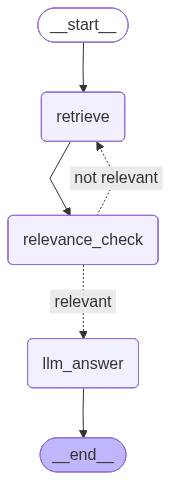

In [11]:
# ---------------------------------------------------
# 그래프 시각화
# ---------------------------------------------------
# 그래프 흐름: START → retrieve → relevance_check → (llm_answer | retrieve) → END
# retrieve: 벡터 검색으로 관련 문서를 찾아요
# relevance_check: 문서 관련성을 yes/no로 평가해요
# 조건부 엣지: 관련 있으면 llm_answer, 없으면 retrieve로 재검색 (무한 루프 위험!)
# relevance_check 노드에서 두 경로로 분기되는 구조가 보여요

from IPython.display import Image, display

display(Image(app_v1.get_graph().draw_mermaid_png()))

In [12]:
# ---------------------------------------------------
# 관련성 있는 질문으로 테스트
# ---------------------------------------------------
# PDF 문서(AI Brief)에 있는 내용을 질문해요

import uuid
from langchain_core.runnables import RunnableConfig
from langgraph.errors import GraphRecursionError

# recursion_limit으로 무한 루프를 방지해요
config = RunnableConfig(
    recursion_limit=10,
    configurable={"thread_id": str(uuid.uuid4())}  # 각 대화에 고유 ID를 부여해요
)

inputs = GraphState(question="앤스로픽에 투자한 기업과 투자금액을 알려주세요.")

# 스트리밍 방식으로 각 노드 결과를 확인해요
for chunk in app_v1.stream(inputs, config, stream_mode="updates"):
    for node_name, node_output in chunk.items():
        print(f"\n--- 노드: {node_name} ---")
        if "relevance" in node_output:
            print(f"관련성: {node_output['relevance']}")
        if "answer" in node_output:
            print(f"답변: {node_output['answer'][:300]}...")


--- 노드: retrieve ---
==== [관련성 체크] ==== yes

--- 노드: relevance_check ---
관련성: yes

--- 노드: llm_answer ---
답변: 앤스로픽에 투자한 기업과 투자금액은 다음과 같습니다:

1. 구글: 최대 20억 달러 (우선 5억 달러 투자)
2. 아마존: 최대 40억 달러 (투자 계획 발표)
3. 마이크로소프트: 30억 달러 (기존 투자) + 100억 달러 (추가 투자)

출처: 데이터 SPIR AI Brief 2023년12월호 F.pdf, 페이지 14....


In [13]:
# ---------------------------------------------------
# 관련성 없는 질문으로 GraphRecursionError 시연
# ---------------------------------------------------
# PDF 문서에 없는 내용을 질문하면 무한 루프 -> GraphRecursionError 발생

config2 = RunnableConfig(
    recursion_limit=8,  # 낮게 설정해 빠르게 오류를 확인해요
    configurable={"thread_id": str(uuid.uuid4())}
)

inputs2 = GraphState(question="파이썬 데코레이터 사용법을 알려주세요.")

try:
    for chunk in app_v1.stream(inputs2, config2, stream_mode="updates"):
        for node_name, node_output in chunk.items():
            if "relevance" in node_output:
                print(f"[{node_name}] 관련성: {node_output['relevance']}")
except GraphRecursionError as e:
    print(f"\nGraphRecursionError 발생! 무한 루프가 감지됐어요.")
    # 다음 섹션에서 웹 검색으로 이 문제를 해결해요.

==== [관련성 체크] ==== no
[relevance_check] 관련성: no
==== [관련성 체크] ==== no
[relevance_check] 관련성: no
==== [관련성 체크] ==== no
[relevance_check] 관련성: no
==== [관련성 체크] ==== no
[relevance_check] 관련성: no

GraphRecursionError 발생! 무한 루프가 감지됐어요.


## 4. 웹 검색 폴백 — 무한 루프 해결

관련성이 없을 때 재검색으로 되돌아가면 무한 루프가 발생해요. 해결 방법은 관련성이 없을 때 **웹 검색(Web Search)**으로 폴백하는 거예요.

> 🔑 **핵심 개념**: 이전 섹션에서 `retrieve → relevance_check → retrieve` 루프가 영원히 반복되는 문제를 봤어요. 웹 검색 폴백은 이 루프의 **탈출구**를 만들어주는 거예요. 관련 문서가 없을 때 "같은 곳을 다시 뒤지는" 대신 "다른 서가(웹)를 찾아보는" 전략이에요.

```mermaid
flowchart LR
    A([질문 입력]) --> B[문서 검색<br/>retrieve]
    B --> C{관련성 체크}
    C -- yes --> D[답변 생성]
    C -- no --> E[웹 검색<br/>web_search]
    E --> D
    D --> F([답변 출력])

    classDef input fill:#d4edda,stroke:#28a745,color:#155724
    classDef process fill:#cce5ff,stroke:#007bff,color:#004085
    classDef output fill:#fff3cd,stroke:#ffc107,color:#856404
    classDef decision fill:#f8d7da,stroke:#dc3545,color:#721c24

    class A input
    class B,D,E process
    class C decision
    class F output
```

> 💡 **실무 팁**: `TavilySearch`를 사용하면 최신 정보(PDF에 없는 내용)도 답변할 수 있어요. `.env`에 `TAVILY_API_KEY`가 필요해요. Tavily API 키는 https://tavily.com 에서 무료로 발급받을 수 있어요.

> ⚠️ **자주 하는 실수**: 웹 검색 결과를 `context`에 저장할 때 기존 `llm_answer` 노드를 그대로 재사용할 수 있어요. 노드를 분리해 두면 입력 소스(PDF든 웹이든)에 관계없이 같은 답변 생성 로직을 쓸 수 있어요 — 이것이 모듈식 설계의 장점이에요.

In [14]:
# ---------------------------------------------------
# Tavily 웹 검색 도구 설정
# ---------------------------------------------------
# langchain-tavily 패키지의 TavilySearch를 사용해요
# TAVILY_API_KEY 환경 변수가 필요해요

from langchain_tavily import TavilySearch

# 웹 검색 도구 초기화 (최대 3개 결과)
tavily_search = TavilySearch(max_results=3)

# 테스트: 2024년 노벨 문학상 수상자
# TavilySearch.invoke()는 {"results": [...], ...} 딕셔너리를 반환해요
test_response = tavily_search.invoke("2024년 노벨 문학상 수상자")
test_result = test_response.get("results", [])
print(f"검색 결과 {len(test_result)}개 반환됨")
print(f"첫 번째 결과 제목: {test_result[0].get('title', 'N/A') if test_result else 'N/A'}")

검색 결과 3개 반환됨
첫 번째 결과 제목: 한강(소설가)/노벨문학상 수상 - 나무위키


In [15]:
# ---------------------------------------------------
# 웹 검색 노드 함수 정의
# ---------------------------------------------------

def web_search(state: GraphState) -> GraphState:
    """관련성 체크 실패 시 웹에서 추가 정보를 검색하는 노드예요."""
    # 사용자 질문으로 웹 검색 수행
    # TavilySearch.invoke()는 {"results": [...], ...} 딕셔너리를 반환해요
    response = tavily_search.invoke(state["question"])
    search_results = response.get("results", [])

    # 검색 결과를 컨텍스트 형태로 포맷팅해요
    context_parts = []
    for result in search_results:
        content = result.get("content", "")
        url = result.get("url", "")
        title = result.get("title", "")
        context_parts.append(
            f"<document><title>{title}</title><content>{content}</content><source>{url}</source></document>"
        )

    context = "\n".join(context_parts)
    print(f"==== [웹 검색 완료] ==== {len(search_results)}개 결과 수집")
    return {"context": context}  # context 필드를 웹 검색 결과로 교체해요

In [16]:
# ---------------------------------------------------
# 웹 검색 폴백 그래프 생성
# ---------------------------------------------------

workflow2 = StateGraph(GraphState)

# 노드 추가 (web_search 노드 추가됨)
workflow2.add_node("retrieve", retrieve_document)
workflow2.add_node("relevance_check", relevance_check)
workflow2.add_node("llm_answer", llm_answer)
workflow2.add_node("web_search", web_search)  # 새로 추가

# 엣지 연결
workflow2.add_edge(START, "retrieve")
workflow2.add_edge("retrieve", "relevance_check")

# 조건부 엣지: 관련 없으면 웹 검색으로 분기해요 (무한 루프 없음!)
workflow2.add_conditional_edges(
    "relevance_check",
    is_relevant,
    {
        "relevant": "llm_answer",   # 관련 있음 -> 답변 생성
        "not relevant": "web_search",  # 관련 없음 -> 웹 검색 (재귀 없음!)
    },
)

workflow2.add_edge("web_search", "llm_answer")  # 웹 검색 -> 답변 생성
workflow2.add_edge("llm_answer", END)

app_v2 = workflow2.compile(checkpointer=MemorySaver())
# 웹 검색 폴백 그래프 컴파일 완료

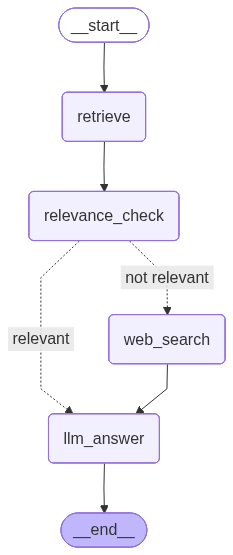

In [17]:
# 그래프 흐름: START → retrieve → relevance_check → (llm_answer | web_search) → llm_answer → END
# retrieve: PDF 벡터 검색으로 관련 문서를 찾아요
# relevance_check: 문서 관련성을 평가해요
# web_search: 관련 문서 없을 때 Tavily로 웹 검색하여 폴백해요 (무한 루프 해결!)
# llm_answer: 검색 결과(PDF 또는 웹)를 기반으로 답변을 생성해요
# 그래프 시각화 -- web_search 노드 확인
from IPython.display import Image, display
display(Image(app_v2.get_graph().draw_mermaid_png()))

In [18]:
# ---------------------------------------------------
# 웹 검색 폴백 테스트 — PDF에 없는 최신 정보
# ---------------------------------------------------
# 2024년 노벨 문학상은 PDF 문서에 없어요 -> 웹 검색으로 폴백해요

config3 = RunnableConfig(
    recursion_limit=10,
    configurable={"thread_id": str(uuid.uuid4())}
)

inputs3 = GraphState(question="2024년 노벨 문학상 수상자는 누구인가요?")

for chunk in app_v2.stream(inputs3, config3, stream_mode="updates"):
    for node_name, node_output in chunk.items():
        print(f"\n--- 노드: {node_name} ---")
        if "relevance" in node_output:
            print(f"관련성: {node_output['relevance']}")
        if "context" in node_output and node_name == "web_search":
            # [웹 검색 결과가 context에 저장됨]
            pass
        if "answer" in node_output:
            print(f"\n[최종 답변]\n{node_output['answer']}")


--- 노드: retrieve ---
==== [관련성 체크] ==== no

--- 노드: relevance_check ---
관련성: no
==== [웹 검색 완료] ==== 3개 결과 수집

--- 노드: web_search ---

--- 노드: llm_answer ---

[최종 답변]
2024년 노벨 문학상 수상자는 한국 소설가 한강(53)입니다. 스웨덴 한림원은 그녀의 작품이 "역사의 트라우마에 맞서고 인간의 취약성을 폭로하는" 점을 높이 평가하여 수여하게 되었습니다. (출처: 통일뉴스)


## 5. 쿼리 재작성 — Query Rewrite

사용자 질문은 대화체이거나 모호한 경우가 많아요. "앤스로픽 투자 금액"처럼 간략한 질문은 벡터 검색에서 관련 문서를 놓칠 수 있어요. 쿼리 재작성(Query Rewrite)을 추가하면 검색 품질을 향상시킬 수 있어요.

> 🔑 **핵심 개념**: `question` 필드를 `List[str]` + `add_messages`로 변경하면 원본 질문과 재작성된 질문을 누적 저장할 수 있어요. `state["question"][-1].content`로 항상 최신 질문을 가져올 수 있어요.

> 💡 **실무 팁**: 쿼리 재작성 프롬프트에 `[REMEMBER] Re-written question should be in the same language as the original question.`을 추가하면 한국어 질문이 영어로 재작성되는 것을 방지할 수 있어요.

In [19]:
# ---------------------------------------------------
# 쿼리 재작성 State — question을 리스트로 변경
# ---------------------------------------------------
# question이 List[str] + add_messages 형태가 되어 원본 + 재작성 질문을 모두 보관해요

from typing import List


class GraphStateV3(TypedDict):
    question: Annotated[List[str], add_messages]  # 질문 히스토리 (원본 + 재작성)
    context: Annotated[str, "검색된 문서"]
    answer: Annotated[str, "생성된 답변"]
    messages: Annotated[list, add_messages]       # 대화 히스토리
    relevance: Annotated[str, "관련성 여부"]

In [20]:
# ---------------------------------------------------
# 쿼리 재작성 체인 정의
# ---------------------------------------------------
# 원본 질문의 의도를 유지하면서 벡터 검색에 최적화된 형태로 재작성해요

from langchain_core.output_parsers import StrOutputParser

re_write_prompt = PromptTemplate(
    template="""아래 질문을 벡터 검색에 최적화된 형태로 재작성해주세요.

규칙:
- 원본 질문의 의도를 유지해요
- 키워드를 명확하게 해요
- 질문 형태는 원본과 같은 언어로 작성해요
- 재작성된 질문만 출력하고, 설명은 포함하지 말아요

원본 질문: {question}

재작성된 질문:""",
    input_variables=["question"],
)

# 쿼리 재작성 체인: 프롬프트 -> LLM -> 문자열 파싱
question_rewriter = (
    re_write_prompt
    | init_chat_model("openai:gpt-4o-mini")
    | StrOutputParser()
)

# 재작성 테스트
original = "앤스로픽 투자 금액"
rewritten = question_rewriter.invoke({"question": original})
print(f"원본:     {original}")
print(f"재작성:   {rewritten}")

원본:     앤스로픽 투자 금액
재작성:   앤스로픽 투자 금액은 얼마인가요?


In [21]:
# ---------------------------------------------------
# GraphStateV3 기반 노드 함수 정의
# ---------------------------------------------------
# question이 리스트이므로 state["question"][-1].content로 최신 질문을 가져와요

def retrieve_document_v3(state: GraphStateV3) -> GraphStateV3:
    """최신(재작성된) 질문으로 PDF 문서를 검색해요."""
    # 리스트의 마지막 요소가 최신 질문이에요 (.content로 텍스트 추출)
    latest_question = state["question"][-1].content
    retrieved_docs = pdf_retriever.invoke(latest_question)
    return {"context": format_docs(retrieved_docs)}


def relevance_check_v3(state: GraphStateV3) -> GraphStateV3:
    """최신 질문으로 관련성을 평가해요."""
    latest_question = state["question"][-1].content
    response = relevance_checker.invoke(
        {"question": latest_question, "context": state["context"]}
    )
    print(f"==== [관련성 체크] ==== {response.score}")
    return {"relevance": response.score}


def llm_answer_v3(state: GraphStateV3) -> GraphStateV3:
    """최신 질문과 컨텍스트로 답변을 생성해요."""
    latest_question = state["question"][-1].content
    chat_history = "\n".join(
        [f"{m.type}: {m.content}" for m in state["messages"]]
    ) if state.get("messages") else ""

    response = pdf_chain.invoke(
        {
            "question": latest_question,
            "context": state["context"],
            "chat_history": chat_history,
        }
    )
    return {
        "answer": response,
        "messages": [("user", latest_question), ("assistant", response)],
    }


def web_search_v3(state: GraphStateV3) -> GraphStateV3:
    """최신 질문으로 웹 검색을 수행해요."""
    latest_question = state["question"][-1].content
    # TavilySearch.invoke()는 {"results": [...], ...} 딕셔너리를 반환해요
    response = tavily_search.invoke(latest_question)
    search_results = response.get("results", [])
    context_parts = [
        f"<document><title>{r.get('title','')}</title><content>{r.get('content','')}</content><source>{r.get('url','')}</source></document>"
        for r in search_results
    ]
    print(f"==== [웹 검색 완료] ==== {len(search_results)}개 결과 수집")
    return {"context": "\n".join(context_parts)}


def query_rewrite(state: GraphStateV3) -> GraphStateV3:
    """사용자 질문을 벡터 검색에 최적화된 형태로 재작성해요."""
    latest_question = state["question"][-1].content
    rewritten = question_rewriter.invoke({"question": latest_question})
    print(f"==== [쿼리 재작성] ====\n원본: {latest_question}\n재작성: {rewritten}")
    # 재작성된 질문을 question 리스트에 추가해요 (add_messages 리듀서로 누적)
    return {"question": rewritten}


def is_relevant_v3(state: GraphStateV3) -> str:
    """관련성에 따라 다음 노드를 결정해요."""
    if state["relevance"] == "yes":
        return "relevant"
    else:
        return "not relevant"

In [22]:
# ---------------------------------------------------
# 쿼리 재작성 포함 그래프 생성
# ---------------------------------------------------
# START -> query_rewrite -> retrieve -> relevance_check -> (llm_answer | web_search)

workflow3 = StateGraph(GraphStateV3)

workflow3.add_node("query_rewrite", query_rewrite)     # 새로 추가: 먼저 질문을 최적화
workflow3.add_node("retrieve", retrieve_document_v3)
workflow3.add_node("relevance_check", relevance_check_v3)
workflow3.add_node("llm_answer", llm_answer_v3)
workflow3.add_node("web_search", web_search_v3)

# query_rewrite가 START 이후 첫 번째 노드예요
workflow3.add_edge(START, "query_rewrite")
workflow3.add_edge("query_rewrite", "retrieve")
workflow3.add_edge("retrieve", "relevance_check")

workflow3.add_conditional_edges(
    "relevance_check",
    is_relevant_v3,
    {
        "relevant": "llm_answer",
        "not relevant": "web_search",
    },
)

workflow3.add_edge("web_search", "llm_answer")
workflow3.add_edge("llm_answer", END)

app_v3 = workflow3.compile(checkpointer=MemorySaver())
# 쿼리 재작성 그래프 컴파일 완료

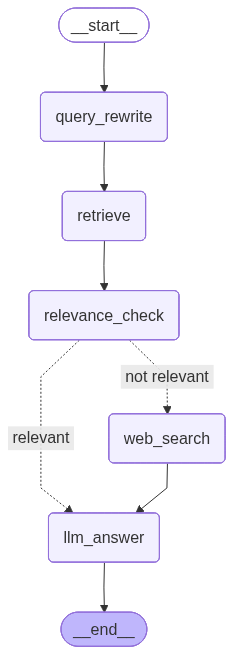

In [23]:
# 그래프 흐름: START → query_rewrite → retrieve → relevance_check → (llm_answer | web_search) → llm_answer → END
# query_rewrite: 벡터 검색에 최적화된 형태로 질문을 재작성해요
# retrieve: 재작성된 질문으로 PDF 벡터 검색을 수행해요
# relevance_check: 검색 문서의 관련성을 평가해요
# web_search: 관련 문서 없을 때 웹 검색으로 폴백해요
# 그래프 시각화 -- query_rewrite 노드 확인
from IPython.display import Image, display
display(Image(app_v3.get_graph().draw_mermaid_png()))

In [24]:
# ---------------------------------------------------
# 쿼리 재작성 테스트 — 간략한 질문
# ---------------------------------------------------
# "앤스로픽 투자 금액"처럼 간략한 질문도 재작성 후 정확하게 검색해요

config4 = RunnableConfig(
    recursion_limit=10,
    configurable={"thread_id": str(uuid.uuid4())}
)

inputs4 = GraphStateV3(question="앤스로픽 투자 금액")

for chunk in app_v3.stream(inputs4, config4, stream_mode="updates"):
    for node_name, node_output in chunk.items():
        print(f"\n--- 노드: {node_name} ---")
        if "relevance" in node_output:
            print(f"관련성: {node_output['relevance']}")
        if "answer" in node_output:
            print(f"\n[최종 답변]\n{node_output['answer']}")

# 원본 질문과 재작성된 질문 비교
final_state = app_v3.get_state(config4).values
print(f"\n원본 질문:   {final_state['question'][0].content}")
print(f"재작성 질문: {final_state['question'][-1].content}")

==== [쿼리 재작성] ====
원본: 앤스로픽 투자 금액
재작성: 앤스로픽 투자 금액은 얼마인가요?

--- 노드: query_rewrite ---

--- 노드: retrieve ---
==== [관련성 체크] ==== yes

--- 노드: relevance_check ---
관련성: yes

--- 노드: llm_answer ---

[최종 답변]
구글은 앤스로픽에 최대 20억 달러를 투자하기로 합의하였고, 그 중 5억 달러를 우선 투자했습니다. 추가로 향후 15억 달러를 더 투자할 계획입니다. (출처: data/SPRI_AI_Brief_2023년12월호_F.pdf, 페이지 14)

원본 질문:   앤스로픽 투자 금액
재작성 질문: 앤스로픽 투자 금액은 얼마인가요?


## 6. Agentic RAG — 완전한 에이전트 기반 시스템

지금까지는 항상 PDF를 먼저 검색했어요. Agentic RAG에서는 LLM 에이전트가 **검색이 필요한지 스스로 판단**해요. PDF와 관련 없는 일반 상식 질문은 검색 없이 바로 답변해요.

> 🎯 **강의 포인트**: `tools_condition`은 에이전트의 마지막 메시지에 `tool_calls`가 있는지 확인해요. 있으면 `tools` 노드로, 없으면 `END`로 라우팅해요. 이것이 에이전트 자율성의 핵심이에요.

> 🔑 **핵심 개념**: `create_retriever_tool`은 Retriever를 LLM이 호출할 수 있는 Tool로 변환해요. 에이전트는 질문에 따라 이 Tool을 호출할지 말지 스스로 결정해요.

> ⚠️ **자주 하는 실수**: Agentic RAG의 `AgentState`는 `messages` 리스트만 있어요. 이전 버전들의 `question`, `context`, `answer`가 없어요. 모든 정보가 메시지 체인 안에 포함되어 있어요.

In [25]:
# ---------------------------------------------------
# 검색 도구 생성 — Retriever를 Tool로 변환
# ---------------------------------------------------
# create_retriever_tool로 PDF 검색을 에이전트 도구로 등록해요

from langchain_core.tools.retriever import create_retriever_tool

# Retriever -> Tool 변환
# 에이전트가 언제 이 도구를 써야 하는지 description에 명확히 적어요
retriever_tool = create_retriever_tool(
    pdf_retriever,
    name="pdf_search",  # 도구 이름
    description=(
        "SPRI AI Brief 문서(2023년 12월호)에서 AI 관련 정보를 검색해요. "
        "AI 기업 투자, 정책, 기술 동향, AI 제품 관련 질문에 사용하세요."
    ),
)

# 도구 리스트
tools = [retriever_tool]

print(f"도구 등록 완료: {retriever_tool.name}")
print(f"설명: {retriever_tool.description}")

도구 등록 완료: pdf_search
설명: SPRI AI Brief 문서(2023년 12월호)에서 AI 관련 정보를 검색해요. AI 기업 투자, 정책, 기술 동향, AI 제품 관련 질문에 사용하세요.


In [26]:
# ---------------------------------------------------
# AgentState 정의 — 메시지 기반 상태
# ---------------------------------------------------
# Agentic RAG는 messages 하나로 모든 상태를 관리해요
# HumanMessage, AIMessage, ToolMessage가 모두 messages에 누적돼요

from langchain_core.messages import BaseMessage


class AgentState(TypedDict):
    # add_messages 리듀서: 새 메시지가 기존 리스트를 덮어쓰지 않고 추가돼요
    messages: Annotated[list[BaseMessage], add_messages]

In [27]:
# ---------------------------------------------------
# 문서 관련성 평가 모델
# ---------------------------------------------------
# GradeDocuments: 검색된 문서가 질문에 관련 있는지 이진 평가해요
# structured_output으로 타입 안전한 yes/no 응답을 받아요

from typing import Literal


class GradeDocuments(BaseModel):
    """검색된 문서의 관련성을 평가하는 이진 점수예요."""

    binary_score: str = Field(
        description="문서가 질문과 관련이 있으면 'yes', 없으면 'no'"
    )


# 관련성 평가 함수 (조건부 엣지로 사용)
def grade_documents(state: AgentState) -> Literal["generate", "rewrite"]:
    """검색된 문서의 관련성을 평가하고 다음 노드를 결정해요."""
    # 관련성 평가용 LLM 설정
    grader_llm = init_chat_model("openai:gpt-4o-mini").with_structured_output(GradeDocuments)

    grade_prompt = PromptTemplate(
        template="""다음 문서가 사용자 질문에 관련이 있는지 평가하세요.

검색된 문서: {context}
사용자 질문: {question}

문서에 질문과 관련된 키워드나 의미가 있으면 'yes', 없으면 'no'로 답하세요.""",
        input_variables=["context", "question"],
    )

    chain = grade_prompt | grader_llm

    # 메시지 체인에서 질문과 검색 결과를 추출해요
    messages = state["messages"]
    question = messages[0].content     # 첫 번째 메시지 = 사용자 질문
    docs = messages[-1].content        # 마지막 메시지 = 도구(검색) 결과

    result = chain.invoke({"question": question, "context": docs})

    if result.binary_score == "yes":
        # ==== [문서 관련 있음] ==== generate로 이동
        return "generate"
    else:
        # ==== [문서 관련 없음] ==== rewrite로 이동
        return "rewrite"

In [28]:
# ---------------------------------------------------
# Agentic RAG 노드 함수 정의
# ---------------------------------------------------

from langchain_core.messages import HumanMessage


def agent(state: AgentState) -> AgentState:
    """도구 사용 여부를 스스로 결정하는 에이전트 노드예요."""
    # 에이전트 LLM에 도구를 바인딩해요
    agent_llm = init_chat_model("openai:gpt-4o-mini").bind_tools(tools)
    response = agent_llm.invoke(state["messages"])
    # tool_calls가 있으면 tools 노드로, 없으면 END로 라우팅돼요
    return {"messages": [response]}


def rewrite(state: AgentState) -> AgentState:
    """관련 문서를 못 찾았을 때 질문을 재작성해 다시 에이전트로 보내요."""
    # ==== [쿼리 재작성 시작] ====
    messages = state["messages"]
    original_question = messages[0].content  # 원본 질문

    # 질문의 의도를 분석해 개선된 질문을 생성해요
    rewrite_msg = [
        HumanMessage(
            content=f"""다음 질문의 핵심 의도를 파악하고 더 명확한 질문으로 개선해주세요.
개선된 질문만 출력하세요 (설명 없이).

원본 질문: {original_question}"""
        )
    ]
    rewrite_llm = init_chat_model("openai:gpt-4o-mini")
    response = rewrite_llm.invoke(rewrite_msg)
    return {"messages": [response]}


def generate(state: AgentState) -> AgentState:
    """검색된 문서를 바탕으로 최종 답변을 생성해요."""
    messages = state["messages"]
    question = messages[0].content  # 원본 질문
    docs = messages[-1].content     # 최신 도구 결과 = 검색된 문서

    # RAG 프롬프트로 답변 생성
    gen_prompt = ChatPromptTemplate.from_messages(
        [
            (
                "system",
                """다음 문서를 바탕으로 질문에 정확하게 답변해주세요.
문서에 없는 내용은 모른다고 솔직하게 말씀해주세요.

문서:
{context}""",
            ),
            ("human", "{question}"),
        ]
    )

    gen_llm = init_chat_model("openai:gpt-4o-mini")
    gen_chain = gen_prompt | gen_llm | StrOutputParser()
    response = gen_chain.invoke({"context": docs, "question": question})
    return {"messages": [response]}

In [29]:
# ---------------------------------------------------
# Agentic RAG 그래프 생성
# ---------------------------------------------------

from langgraph.prebuilt import ToolNode, tools_condition

agentic_workflow = StateGraph(AgentState)

# 노드 등록
agentic_workflow.add_node("agent", agent)
agentic_workflow.add_node("retrieve", ToolNode([retriever_tool]))  # ToolNode로 래핑
agentic_workflow.add_node("rewrite", rewrite)
agentic_workflow.add_node("generate", generate)

# 시작 -> 에이전트
agentic_workflow.add_edge(START, "agent")

# 에이전트 -> 도구 호출 여부에 따라 분기
# tools_condition: tool_calls 있으면 "tools", 없으면 END
agentic_workflow.add_conditional_edges(
    "agent",
    tools_condition,    # 에이전트 도구 호출 판단
    {
        "tools": "retrieve",  # 도구 호출 -> PDF 검색
        END: END,             # 도구 불필요 -> 바로 종료
    },
)

# 검색 후 문서 관련성 평가
# grade_documents가 직접 "generate" 또는 "rewrite" 문자열을 반환해요
agentic_workflow.add_conditional_edges(
    "retrieve",
    grade_documents,   # 문서 품질 평가
)

agentic_workflow.add_edge("generate", END)
agentic_workflow.add_edge("rewrite", "agent")  # 재작성 후 에이전트로 다시!

# 컴파일
agentic_graph = agentic_workflow.compile(checkpointer=MemorySaver())
# Agentic RAG 그래프 컴파일 완료

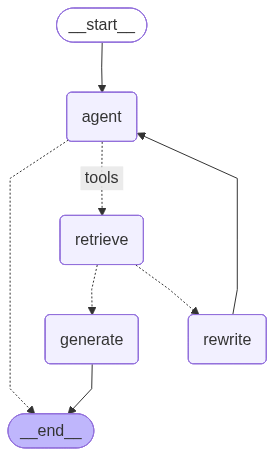

In [30]:
# 그래프 흐름: START → agent → (retrieve | END) → grade_documents → (generate | rewrite) → END
# agent: 도구 사용 여부를 자율적으로 판단해요 (tools_condition으로 분기)
# retrieve: ToolNode로 PDF 검색 도구를 실행해요
# grade_documents: 검색 문서의 관련성을 평가하여 generate 또는 rewrite로 분기해요
# rewrite: 질문을 재작성하여 agent로 다시 보내요
# generate: 최종 답변을 생성해요
# 그래프 시각화 -- Agentic RAG 전체 구조
from IPython.display import Image, display
display(Image(agentic_graph.get_graph().draw_mermaid_png()))

In [31]:
# ---------------------------------------------------
# Agentic RAG 테스트 1 — PDF 검색이 필요한 질문
# ---------------------------------------------------
# 삼성 가우스 정보는 PDF에 있어요 -> 에이전트가 도구를 호출해요

config5 = RunnableConfig(
    recursion_limit=10,
    configurable={"thread_id": str(uuid.uuid4())}
)

inputs5 = {
    "messages": [
        ("user", "삼성전자가 개발한 생성형 AI의 이름은 무엇인가요?")
    ]
}

for chunk in agentic_graph.stream(inputs5, config5, stream_mode="updates"):
    for node_name, node_output in chunk.items():
        print(f"\n--- 노드: {node_name} ---")
        if "messages" in node_output:
            last_msg = node_output["messages"][-1]
            # AIMessage는 내용이 길면 생략해요
            content = getattr(last_msg, 'content', str(last_msg))
            if content and node_name in ["generate", "agent"]:
                print(content[:500])


--- 노드: agent ---

--- 노드: retrieve ---

--- 노드: generate ---
삼성전자가 개발한 생성형 AI의 이름은 '삼성 가우스'입니다.


In [32]:
# ---------------------------------------------------
# Agentic RAG 테스트 2 — 검색 불필요한 일반 상식 질문
# ---------------------------------------------------
# 대한민국 수도는 일반 상식 -> 에이전트가 도구 없이 바로 답변해요

config6 = RunnableConfig(
    recursion_limit=10,
    configurable={"thread_id": str(uuid.uuid4())}
)

inputs6 = {
    "messages": [
        ("user", "대한민국의 수도는 어디인가요?")
    ]
}

for chunk in agentic_graph.stream(inputs6, config6, stream_mode="updates"):
    for node_name, node_output in chunk.items():
        print(f"\n--- 노드: {node_name} ---")
        if "messages" in node_output:
            last_msg = node_output["messages"][-1]
            content = getattr(last_msg, 'content', str(last_msg))
            if content:
                print(content[:300])

# -> 도구 호출 없이 에이전트가 직접 답변했어요!


--- 노드: agent ---
대한민국의 수도는 서울입니다.


In [33]:
# ---------------------------------------------------
# Agentic RAG 테스트 3 — GraphRecursionError 시연
# ---------------------------------------------------
# PDF에 없는 내용을 PDF에서 찾으라고 하면 -> rewrite -> agent -> retrieve 루프
# recursion_limit으로 방어해요

from langgraph.errors import GraphRecursionError

config7 = RunnableConfig(
    recursion_limit=6,  # 낮게 설정해 빠르게 확인
    configurable={"thread_id": str(uuid.uuid4())}
)

# PDF 문서에 없는 내용을 PDF에서 찾으라고 강제해요
inputs7 = {
    "messages": [
        ("user", "SPRI AI Brief 문서에서 파이썬 데코레이터 구현 방법을 찾아서 알려줘")
    ]
}

try:
    for chunk in agentic_graph.stream(inputs7, config7, stream_mode="updates"):
        for node_name, node_output in chunk.items():
            if node_name in ["rewrite", "agent"]:
                print(f"[{node_name}] 처리 중...")
except GraphRecursionError as e:
    print(f"\nGraphRecursionError 발생!")
    # 실제 서비스에서는 이 오류를 잡아서 사용자에게 안내 메시지를 보내야 해요.

[agent] 처리 중...
[rewrite] 처리 중...
[agent] 처리 중...
[rewrite] 처리 중...

GraphRecursionError 발생!


## 7. 실습 해설 — Agentic RAG 도구 확장

아래 완성 예제는 기존 `pdf_search`에 `web_search`를 추가해서, 질문 성격에 따라 에이전트가 **PDF 검색** 또는 **웹 검색**을 직접 선택하도록 만듭니다.

In [34]:
# ============================================================
# 실습 해설: Tavily 웹 검색을 두 번째 도구로 추가해요
#
# 예상 결과:
#   - PDF 관련 질문: pdf_search 도구 사용
#   - 최신 뉴스 질문: web_search 도구 사용
#   - 에이전트가 어떤 도구를 사용할지 스스로 선택해요
# ============================================================

from langchain_tavily import TavilySearch

web_search_tool = TavilySearch(max_results=3, name="web_search")
tools_extended = [retriever_tool, web_search_tool]


def agent_extended(state: AgentState) -> AgentState:
    """PDF 검색과 웹 검색 중 필요한 도구를 스스로 선택하는 에이전트 노드예요."""
    agent_llm = init_chat_model("openai:gpt-4o-mini").bind_tools(tools_extended)
    response = agent_llm.invoke(state["messages"])
    return {"messages": [response]}


agentic_workflow_extended = StateGraph(AgentState)
agentic_workflow_extended.add_node("agent", agent_extended)
agentic_workflow_extended.add_node("retrieve", ToolNode(tools_extended))
agentic_workflow_extended.add_node("rewrite", rewrite)
agentic_workflow_extended.add_node("generate", generate)
agentic_workflow_extended.add_edge(START, "agent")
agentic_workflow_extended.add_conditional_edges(
    "agent",
    tools_condition,
    {"tools": "retrieve", END: END},
)
agentic_workflow_extended.add_conditional_edges("retrieve", grade_documents)
agentic_workflow_extended.add_edge("generate", END)
agentic_workflow_extended.add_edge("rewrite", "agent")

agentic_graph_extended = agentic_workflow_extended.compile(checkpointer=MemorySaver())
print(f"확장 도구 목록: {[tool.name for tool in tools_extended]}")

extended_config = RunnableConfig(
    recursion_limit=10,
    configurable={"thread_id": str(uuid.uuid4())},
)
extended_inputs = {
    "messages": [
        (
            "user",
            "삼성전자가 개발한 생성형 AI의 2026년 최신 근황을 알려줘",
        )
    ]
}

for chunk in agentic_graph_extended.stream(
    extended_inputs,
    extended_config,
    stream_mode="updates",
):
    for node_name, node_output in chunk.items():
        print(f"\n--- 노드: {node_name} ---")
        if "messages" in node_output:
            last_msg = node_output["messages"][-1]
            tool_calls = getattr(last_msg, "tool_calls", None)
            if tool_calls:
                print(f"도구 호출: {[call['name'] for call in tool_calls]}")
            content = getattr(last_msg, "content", "")
            if content:
                print(str(content)[:500])

확장 도구 목록: ['pdf_search', 'web_search']

--- 노드: agent ---
도구 호출: ['pdf_search']

--- 노드: retrieve ---
SPRi AI Brief |
2023-12월호
삼성전자, 자체 개발 생성 AI ‘삼성 가우스’ 공개
KEY Contents
n 삼성전자가 온디바이스에서 작동 가능하며 언어, 코드, 이미지의 3개 모델로 구성된 자체 개발 생성
AI 모델 ‘삼성 가우스’를 공개
n 삼성전자는 삼성 가우스를 다양한 제품에 단계적으로 탑재할 계획으로, 온디바이스 작동이 가능한
삼성 가우스는 외부로 사용자 정보가 유출될 위험이 없다는 장점을 보유
£언어, 코드, 이미지의 3개 모델로 구성된 삼성 가우스, 온디바이스 작동 지원
n 삼성전자가 2023년 11월 8일 열린 ‘삼성 AI 포럼 2023’ 행사에서 자체 개발한 생성 AI 모델
‘삼성 가우스’를 최초 공개
∙ 정규분포 이론을 정립한 천재 수학자 가우스(Gauss)의 이름을 본뜬 삼성 가우스는 다양한 상황에
최적화된 크기의 모델 선택이 가능
∙ 삼성 가우스는 라이선스나 개인정보를 침해하지 않는 안전한 데이터를 통해 학습되었으며,
온디바이스에서 작동하도록 

--- 노드: rewrite ---
삼성전자가 개발한 생성형 AI의 2026년 최신 개발 현황은 무엇인가요?

--- 노드: agent ---
삼성전자가 2026년을 목표로 개발 중인 생성형 AI 모델인 '삼성 가우스(Samsung Gauss)'는 여러 최신 기술 기능을 갖추고 있습니다. 최근에 공개된 내용에 따르면, 삼성 가우스는 온디바이스에서 작동할 수 있으며, 언어, 코드, 이미지의 세 가지 모델로 구성됩니다. 이 AI 모델의 특징과 발전 내용은 다음과 같습니다:

1. **구성 모델**:
   - **언어 모델**: 문서 작성, 요약, 번역 등을 지원하며, 다양한 환경에 맞춰 클라우드 및 온디바이스에서 작동할 수 있는 모델이 마련되어 있습니다.
   - **코드 모델**: '코드아이(code.

## 핵심 요약

이 노트북에서 다음 내용을 배웠어요:

- **관련성 체크(Groundedness Check)**: `with_structured_output()`과 Pydantic 모델로 검색 문서의 관련성을 이진 평가해요
- **조건부 엣지(Conditional Edges)**: `add_conditional_edges()`와 라우팅 함수로 관련성에 따라 흐름을 분기해요
- **웹 검색 폴백**: `TavilySearch`를 폴백으로 추가해 무한 루프 없이 PDF에 없는 내용도 답변해요
- **쿼리 재작성(Query Rewrite)**: `question` 필드를 `List[str]`로 관리해 원본과 재작성 질문을 모두 보존해요
- **Agentic RAG**: `create_retriever_tool` + `ToolNode` + `tools_condition`으로 에이전트가 검색 여부를 스스로 결정해요
- **GradeDocuments**: Pydantic `BaseModel` + `with_structured_output()`으로 타입 안전한 문서 관련성 평가를 구현해요
- **GraphRecursionError**: `recursion_limit`과 예외 처리로 무한 루프를 방어해요

### 이 노트북에서 구현한 4가지 버전 비교

| 버전 | 핵심 추가 기능 | 무한 루프 방어 | LLM 호출 횟수 |
|------|--------------|---------------|--------------|
| **v1** 관련성 체크 | Groundedness Check | `recursion_limit`만 | 2-3회 (검색+평가+생성) |
| **v2** 웹 검색 폴백 | Tavily 웹 검색 | 웹 검색으로 탈출 | 3-4회 |
| **v3** 쿼리 재작성 | Query Rewrite | 웹 검색으로 탈출 | 4-5회 |
| **v4** Agentic RAG | 에이전트 자율 판단 | 재작성 + `recursion_limit` | 가변 (에이전트 판단) |

## 다음 노트북 예고

다음 `03-CRAG-Self-RAG.ipynb`에서는 **Corrective RAG(CRAG)와 Self-RAG**를 배워요. CRAG는 검색 결과를 평가하고 필요하면 쿼리를 수정 후 재검색하는 방식이에요. Self-RAG는 검색 여부, 검색 결과 활용 여부, 최종 답변의 환각 여부를 모두 LLM이 스스로 판단해요.